# Strain-Space Stiffness vs Strain

Load one or more saved architecture-run directories containing `config.json` and `model.eqx`, compute the Hessian of the learned energy with respect to the full strain vector, and overlay selected Hessian entries against selected strain components.

The defaults plot `H[0, 0]` against `strain[0]` and `H[1, 1]` against `strain[3]`. Edit `PLOT_SPECS` if you want, for example, `H[3, 3]` against `strain[3]` instead.

In [1]:
from pathlib import Path

# Paste architecture run directories here. Each directory must contain config.json and model.eqx.
EXPERIMENT_DIRS = [
    Path("arch_sweep_outputs_n11_tape_all_architectures_train_fail_on_nonconvergence_True")
    / "brazier_chol_stiffness_icnn__hid_10__inp_raw__stretchNN_0__bendNN_0__act_tanh__corr_0.01__zr1__seed_42__mdl_0.05__it_10__hreg_1e-06__hprobe_1__hseed_0__wd_1e-05__mode_anisotropic",
    # Path("arch_sweep_outputs_n11_tape_all_architectures_train_fail_on_nonconvergence_True")
    # / "brazier_chol_stiffness_mlp__hid_10__inp_raw__stretchNN_0__bendNN_0__act_tanh__corr_0.01__zr1__seed_42__mdl_0.05__it_10__hreg_1e-06__hprobe_1__hseed_0__wd_1e-05__mode_anisotropic",
    # Path("arch_sweep_outputs_n11_tape_all_architectures_train_fail_on_nonconvergence_True")
    # / "brazier_diag_stiffness_icnn__hid_10__inp_raw__stretchNN_0__bendNN_0__act_tanh__corr_0.01__zr1__seed_42__mdl_0.05__it_10__hreg_1e-06__hprobe_1__hseed_0__wd_1e-05__mode_anisotropic",
]

# Use the saved trajectory states by default. Set to "pred" to solve predicted paths per model, or "both".
SOURCE = "true"  # "true", "pred", or "both"
SPLITS = ("train", "valid")

# The Hessian is computed with respect to the full strain vector returned by the rod.
# For the 3D rod here: strain = [eps0, eps1, kappa1, kappa2, tau].
PLOT_SPECS = [
    {"hessian_index": (0, 0), "strain_index": 0, "title": "H[0,0] vs strain[0]"},
    {"hessian_index": (3, 3), "strain_index": 3, "title": "H[3,3] vs strain[3]"},
]

# Scatter shows actual trajectory samples. The solid line is a binned median over those samples.
# The dashed line is a 1D slice: vary the x strain and hold all other strains at their median.
N_BINS = 40
PLOT_SCATTER = True
PLOT_BINNED_MEDIAN = True
PLOT_1D_SLICE = True
SLICE_N = 301
SAVE_FIG = False
FIG_PATH = Path("strain_space_stiffness_vs_strain.png")

In [2]:
import json
import os
import sys
from dataclasses import fields

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

SCRIPT_DIR = Path.cwd().resolve()
if SCRIPT_DIR.name != "slinky_2D":
    # If launched from the repo root, move to this notebook's usual directory.
    candidate = SCRIPT_DIR / "examples" / "slinky" / "slinky_2D"
    if candidate.is_dir():
        os.chdir(candidate)
        SCRIPT_DIR = candidate.resolve()

REPO_ROOT = SCRIPT_DIR.parents[2]
sys.path.insert(0, str(SCRIPT_DIR))
sys.path.insert(0, str(REPO_ROOT / "src"))

import dismech_jax as djx
from dismech_jax.solver import update_aux_state

import properties as properties_module
from run_architectures import SweepConfig, build_architecture_registry, make_model_params
from util import Dataset, get_slinky


def resolve_path(path):
    path = Path(path).expanduser()
    if path.is_absolute():
        return path.resolve()
    return (SCRIPT_DIR / path).resolve()


def sweep_config_from_payload(payload):
    field_names = {f.name for f in fields(SweepConfig)}
    kwargs = {key: value for key, value in payload.items() if key in field_names}
    tuple_keys = {
        "der_K_diag",
        "der_K_chol",
        "hidden",
        "force_components",
        "hessian_diagnostics_splits",
        "seed_list",
        "energy_snapshot_epochs",
    }
    for key in tuple_keys:
        if key in kwargs and kwargs[key] is not None:
            kwargs[key] = tuple(kwargs[key])
    kwargs.pop("energy_landscape_spec", None)
    return SweepConfig(**kwargs)


def properties_from_payload(payload):
    prop_payload = payload["properties"]
    prop_cls = getattr(properties_module, prop_payload["class_name"])
    valid_fields = {f.name for f in fields(prop_cls)}
    return prop_cls(**{k: v for k, v in prop_payload.items() if k in valid_fields})


def load_run(exp_dir):
    exp_dir = resolve_path(exp_dir)
    with (exp_dir / "config.json").open() as f:
        payload = json.load(f)
    cfg = sweep_config_from_payload(payload)
    spec = build_architecture_registry()[payload["arch_name"]]
    params = make_model_params(cfg, spec)
    model = eqx.tree_deserialise_leaves(exp_dir / "model.eqx", spec.model_cls(params))
    base, aux0 = get_slinky(properties_from_payload(payload))
    label = payload.get("arch_name", exp_dir.name)
    return {"exp_dir": exp_dir, "payload": payload, "cfg": cfg, "spec": spec, "model": model, "base": base, "aux0": aux0, "label": label}


def source_list():
    if SOURCE == "both":
        return ("true", "pred")
    if SOURCE not in {"true", "pred"}:
        raise ValueError("SOURCE must be 'true', 'pred', or 'both'.")
    return (SOURCE,)


def collect_full_strains(run, split, source):
    payload, cfg, model, base, aux0 = run["payload"], run["cfg"], run["model"], run["base"], run["aux0"]
    data = Dataset.load(payload[f"{split}_file"], force_key=cfg.force_key)

    qs_all = np.asarray(data.qs)
    xb_all = np.asarray(data.xb)
    valid_all = np.asarray(data.valid, dtype=bool)
    lam_all = np.broadcast_to(np.asarray(data.lambdas), valid_all.shape) if data.lambdas.ndim == 1 else np.asarray(data.lambdas)
    idx_all = np.broadcast_to(np.asarray(data.idx_b), (qs_all.shape[0], data.idx_b.shape[0])) if data.idx_b.ndim == 1 else np.asarray(data.idx_b)

    strains = []
    meta = []
    for traj_idx in range(qs_all.shape[0]):
        valid_idx = np.where(valid_all[traj_idx])[0]
        if valid_idx.size == 0:
            continue

        qs = qs_all[traj_idx, valid_idx]
        xb = xb_all[traj_idx, valid_idx]
        lambdas = lam_all[traj_idx, valid_idx]
        rod = base.with_bc(djx.DirectBC(idx_b=jnp.asarray(idx_all[traj_idx]), xb=jnp.asarray(xb), lambdas=jnp.asarray(lambdas)))

        if source == "pred":
            qs = np.asarray(
                rod.solve(
                    model,
                    jnp.asarray(lambdas),
                    aux0,
                    max_dlambda=cfg.max_dlambda,
                    iters=cfg.iters,
                    ls_steps=cfg.ls_steps,
                    abs_tol=cfg.abs_tol,
                    rel_tol=cfg.rel_tol,
                    fail_on_nonconvergence=False,
                    early_stop=cfg.early_stop,
                )
            )

        for state_idx, (_lambda, q) in enumerate(zip(lambdas, qs)):
            q = jnp.asarray(q)
            aux_q = update_aux_state(aux0, q, rod)
            full_strains = np.asarray(rod.get_del_strains(q, aux_q))
            for triplet_idx, eps in enumerate(full_strains):
                strains.append(eps)
                meta.append((split, source, traj_idx, state_idx, triplet_idx, float(_lambda)))

    return np.asarray(strains), meta


def collect_run_strains(run):
    blocks = []
    meta = []
    for split in SPLITS:
        for source in source_list():
            s, m = collect_full_strains(run, split, source)
            blocks.append(s)
            meta.extend(m)
    return np.concatenate(blocks, axis=0), meta


def hessian_values_for_strains(model, strains, hessian_index):
    i, j = hessian_index

    @jax.jit
    def one(eps):
        hess = jax.hessian(lambda x: model(x))(eps)
        hess = 0.5 * (hess + hess.T)
        return hess[i, j]

    return np.asarray(jax.jit(jax.vmap(one))(jnp.asarray(strains)))


def binned_median(x, y, n_bins):
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    chunks = np.array_split(np.arange(x_sorted.size), min(n_bins, x_sorted.size))
    bx = np.array([np.median(x_sorted[c]) for c in chunks if c.size])
    by = np.array([np.median(y_sorted[c]) for c in chunks if c.size])
    return bx, by


def one_dimensional_slice(run, strains, plot_spec):
    base_eps = np.median(strains, axis=0)
    x_idx = plot_spec["strain_index"]
    xs = np.linspace(np.min(strains[:, x_idx]), np.max(strains[:, x_idx]), SLICE_N)
    eps_grid = np.repeat(base_eps[None, :], SLICE_N, axis=0)
    eps_grid[:, x_idx] = xs
    ys = hessian_values_for_strains(run["model"], eps_grid, plot_spec["hessian_index"])
    return xs, ys

In [3]:
runs = [load_run(path) for path in EXPERIMENT_DIRS]
for run in runs:
    strains, meta = collect_run_strains(run)
    run["strains"] = strains
    run["meta"] = meta
    print(f"{run['label']}: {strains.shape[0]} strain samples, strain_dim={strains.shape[1]}, dir={run['exp_dir']}")
    print("  strain min:", np.min(strains, axis=0))
    print("  strain max:", np.max(strains, axis=0))

/var/folders/z0/3frv2l990hb5ryd49z8vm4w80000gn/T/ipykernel_42293/811068852.py:75: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux0 = get_slinky(properties_from_payload(payload))


brazier_chol_stiffness_icnn: 378 strain samples, strain_dim=5, dir=/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/arch_sweep_outputs_n11_tape_all_architectures_train_fail_on_nonconvergence_True/brazier_chol_stiffness_icnn__hid_10__inp_raw__stretchNN_0__bendNN_0__act_tanh__corr_0.01__zr1__seed_42__mdl_0.05__it_10__hreg_1e-06__hprobe_1__hseed_0__wd_1e-05__mode_anisotropic
  strain min: [-0.42815498 -0.39794227  0.         -1.07811275  0.        ]
  strain max: [0.44276938 0.33401277 0.         0.98873819 0.        ]


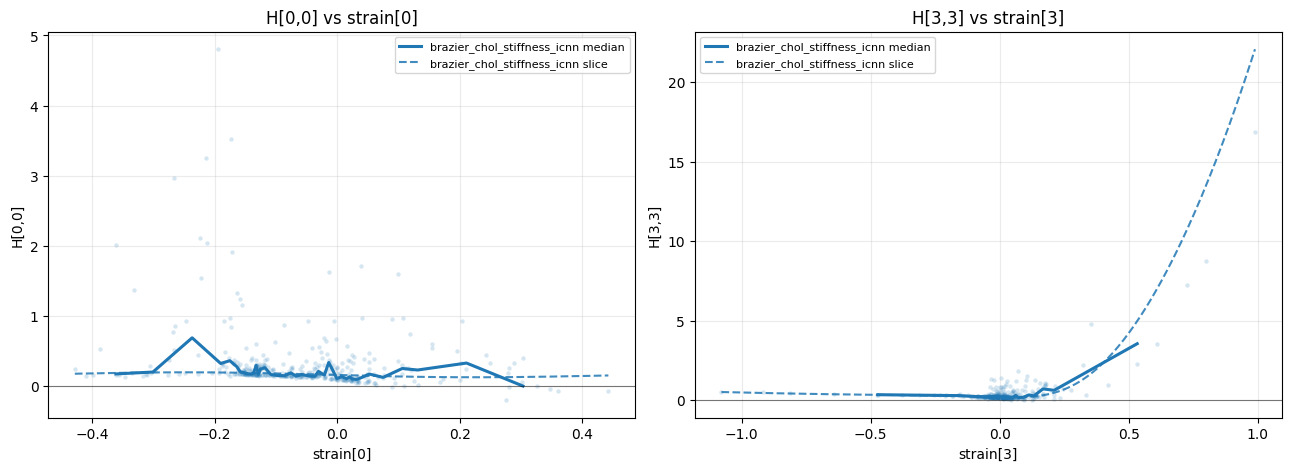

In [4]:
fig, axes = plt.subplots(1, len(PLOT_SPECS), figsize=(6.4 * len(PLOT_SPECS), 4.6), constrained_layout=True)
if len(PLOT_SPECS) == 1:
    axes = [axes]

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, plot_spec in zip(axes, PLOT_SPECS):
    h_idx = plot_spec["hessian_index"]
    x_idx = plot_spec["strain_index"]
    for run_idx, run in enumerate(runs):
        color = colors[run_idx % len(colors)]
        strains = run["strains"]
        x = strains[:, x_idx]
        y = hessian_values_for_strains(run["model"], strains, h_idx)

        if PLOT_SCATTER:
            ax.scatter(x, y, s=10, alpha=0.18, color=color, linewidths=0)

        if PLOT_BINNED_MEDIAN:
            bx, by = binned_median(x, y, N_BINS)
            ax.plot(bx, by, color=color, linewidth=2.2, label=f"{run['label']} median")

        if PLOT_1D_SLICE:
            sx, sy = one_dimensional_slice(run, strains, plot_spec)
            ax.plot(sx, sy, color=color, linestyle="--", linewidth=1.5, alpha=0.85, label=f"{run['label']} slice")

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(plot_spec.get("title", f"H{h_idx} vs strain[{x_idx}]"))
    ax.set_xlabel(f"strain[{x_idx}]")
    ax.set_ylabel(f"H[{h_idx[0]},{h_idx[1]}]")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

if SAVE_FIG:
    fig.savefig(FIG_PATH, dpi=220, bbox_inches="tight")
    print(f"saved {FIG_PATH.resolve()}")

plt.show()

## Tangent Hessian vs Explicit K Decomposition

Use this diagnostic when a Hessian entry does not look like the explicit stiffness law you expected. For models of the form `E(eps) = 0.5 * eps.T @ K(eps) @ eps`, the Hessian is the tangent stiffness, not just `K(eps)`: it also includes derivatives of `K` with respect to strain.

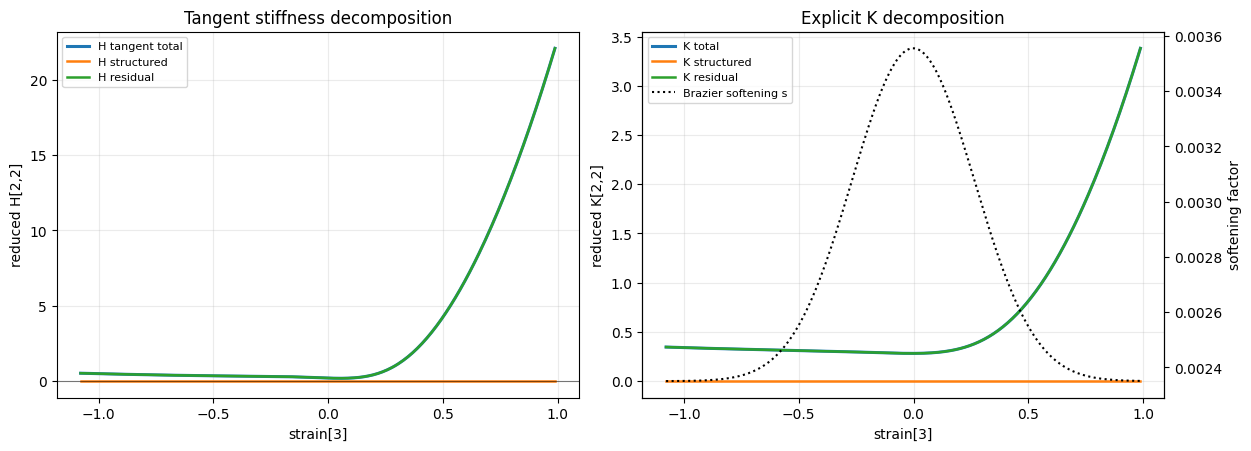

Brazier params [rho_min, kappa_c_pos, kappa_c_neg, alpha_pos, alpha_neg]:
[0.0023503992102986877, 0.34587725104629935, 0.34936533130855424, 11.75902492892759, 11.770481436381932]
At these slice points, the structured contribution is tiny compared with the learned residual when the residual curves dominate.


In [5]:
# Diagnostic for the default bending panel. For this 3D rod, strain[3] is kappa2.
# Structured Brazier models reduce full strain [eps0, eps1, kappa1, kappa2, tau]
# to [eps0, eps1, kappa2], so full H[3,3] equals reduced H[2,2].

DIAGNOSTIC_RUN_INDEX = 0
DIAGNOSTIC_FULL_STRAIN_INDEX = 3
DIAGNOSTIC_REDUCED_INDEX = 2

run = runs[DIAGNOSTIC_RUN_INDEX]
model = run["model"]
strains = run["strains"]
x = strains[:, DIAGNOSTIC_FULL_STRAIN_INDEX]
base_reduced = np.median(strains[:, [0, 1, 3]], axis=0)
xs = np.linspace(np.min(x), np.max(x), SLICE_N)

def reduced_energy(r):
    return model(r)

def structured_energy(r):
    return 0.5 * r @ model.get_structured_K(r) @ r

def residual_energy(r):
    return 0.5 * r @ model.get_residual_K(r) @ r

@jax.jit
def diagnostic_values(r):
    h_total = jax.hessian(reduced_energy)(r)
    h_struct = jax.hessian(structured_energy)(r)
    h_resid = jax.hessian(residual_energy)(r)
    K_struct = model.get_structured_K(r)
    K_resid = model.get_residual_K(r)
    K_total = K_struct + K_resid
    i = DIAGNOSTIC_REDUCED_INDEX
    return jnp.array([
        h_total[i, i],
        h_struct[i, i],
        h_resid[i, i],
        K_total[i, i],
        K_struct[i, i],
        K_resid[i, i],
        model.brazier_softening_factor(r[i]),
    ])

slice_reduced = np.repeat(base_reduced[None, :], SLICE_N, axis=0)
slice_reduced[:, DIAGNOSTIC_REDUCED_INDEX] = xs
vals = np.asarray(jax.jit(jax.vmap(diagnostic_values))(jnp.asarray(slice_reduced)))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), constrained_layout=True)
axes[0].plot(xs, vals[:, 0], label="H tangent total", linewidth=2.2)
axes[0].plot(xs, vals[:, 1], label="H structured", linewidth=1.8)
axes[0].plot(xs, vals[:, 2], label="H residual", linewidth=1.8)
axes[0].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_xlabel(f"strain[{DIAGNOSTIC_FULL_STRAIN_INDEX}]")
axes[0].set_ylabel(f"reduced H[{DIAGNOSTIC_REDUCED_INDEX},{DIAGNOSTIC_REDUCED_INDEX}]")
axes[0].set_title("Tangent stiffness decomposition")
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(xs, vals[:, 3], label="K total", linewidth=2.2)
axes[1].plot(xs, vals[:, 4], label="K structured", linewidth=1.8)
axes[1].plot(xs, vals[:, 5], label="K residual", linewidth=1.8)
ax2 = axes[1].twinx()
ax2.plot(xs, vals[:, 6], color="black", linestyle=":", label="Brazier softening s")
axes[1].set_xlabel(f"strain[{DIAGNOSTIC_FULL_STRAIN_INDEX}]")
axes[1].set_ylabel(f"reduced K[{DIAGNOSTIC_REDUCED_INDEX},{DIAGNOSTIC_REDUCED_INDEX}]")
ax2.set_ylabel("softening factor")
axes[1].set_title("Explicit K decomposition")
axes[1].grid(True, alpha=0.25)
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines + lines2, labels + labels2, fontsize=8)

plt.show()

print("Brazier params [rho_min, kappa_c_pos, kappa_c_neg, alpha_pos, alpha_neg]:")
print([float(v) for v in model.get_brazier_params()])
print("At these slice points, the structured contribution is tiny compared with the learned residual when the residual curves dominate.")

Notes:

- The scatter points are Hessian values at actual trajectory triplet strains.
- The solid line is a binned median through those scatter points, useful when different trajectory states share similar x-strain values.
- The dashed line is a controlled 1D slice: the plotted strain component varies over its observed range while all other strain components are held at their median value.
- Since the Hessian is computed with respect to the full strain vector, the default second panel is literally `H[1,1]` plotted against `strain[3]`. If you meant bending stiffness against bending strain, set `hessian_index` to `(3, 3)` for that panel.